In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns
import sys

In [2]:
sys.path.append("C:/Users/MSI Modern/Downloads/EDA_on_NOAA_ADAPC_Dataset.csv")

#JupyterNotebook和Python要读取指定本地文件夹方法，只需在代码前增加两行代码：
#import sys
#sys.path.append(D：工作文件) #换成目标路径即可。
#Credit: https://blog.csdn.net/weixin_42508806/article/details/126398690

In [3]:
df= pd.read_csv("C:/Users/MSI Modern/Downloads/EDA_on_NOAA_ADAPC_Dataset.csv")

#Read in the 2018 lightning stirke dataset
#df= pd.read_csv("C:\Users\MSI Modern\Downloads\EDA on NOAA, GADAPC Dataset.csv"), for others such as Jupyter/Pycharm

In [6]:
df['date']=pd.to_datetime(df['date'])

#Current date format= 2016-08-09

#datetime use to convert date column to datetime
#Exp= df['date']=pd.to_datetime(df['date'])
#It separate date points into Year, Month, and Day

In [7]:
df.head(10)

#Return the rows request in the()

,date,number_of_strikes,center_point_geom
0,2016-08-05,16,POINT(-101.5 24.7)
1,2016-08-05,16,POINT(-85 34.3)
2,2016-08-05,16,POINT(-89 41.4)
3,2016-08-05,16,POINT(-89.8 30.7)
4,2016-08-05,16,POINT(-86.2 37.9)
5,2016-08-05,16,POINT(-97.8 38.9)
6,2016-08-05,16,POINT(-81.9 36)
7,2016-08-05,16,POINT(-90.9 36.7)
8,2016-08-05,16,POINT(-106.6 26.1)
9,2016-08-05,16,POINT(-108 31.6)


In [8]:
#Create new "Month" column
df['Month']= df['date'].dt.month

df.head()

,date,number_of_strikes,center_point_geom,Month
0,2016-08-05,16,POINT(-101.5 24.7),8
1,2016-08-05,16,POINT(-85 34.3),8
2,2016-08-05,16,POINT(-89 41.4),8
3,2016-08-05,16,POINT(-89.8 30.7),8
4,2016-08-05,16,POINT(-86.2 37.9),8


In [9]:
#To make it easier interpret on a chart
#Convert the month data which are currently numbers to month name abbreviations
#So create another column ['Month_txt'], take the string of characters or month names and slice to include only the first 3 letters

df['Month_txt']= df['date'].dt.month_name().str.slice(stop=3)
df.head()

,date,number_of_strikes,center_point_geom,Month,Month_txt
0,2016-08-05,16,POINT(-101.5 24.7),8,Aug
1,2016-08-05,16,POINT(-85 34.3),8,Aug
2,2016-08-05,16,POINT(-89 41.4),8,Aug
3,2016-08-05,16,POINT(-89.8 30.7),8,Aug
4,2016-08-05,16,POINT(-86.2 37.9),8,Aug


In [10]:
# Sort by number of strikes in descending order
df.sort_values(by='number_of_strikes', ascending=False).head(10)

,date,number_of_strikes,center_point_geom,Month,Month_txt
1208433,2016-05-26,2386,POINT(-96.3 30.3),5,May
106830,2017-04-11,2330,POINT(-97.7 31.2),4,Apr
3323180,2016-08-07,2271,POINT(-84 29),8,Aug
7441365,2017-04-11,2242,POINT(-97.6 31.2),4,Apr
2167347,2018-08-20,2211,POINT(-92.5 35.5),8,Aug
4260229,2018-08-16,2142,POINT(-96.1 36.1),8,Aug
5397540,2016-05-26,2095,POINT(-96.2 30.3),5,May
6356003,2018-08-17,2061,POINT(-90.2 36.1),8,Aug
7404862,2018-08-17,2031,POINT(-89.9 35.9),8,Aug
70627,2018-08-16,1902,POINT(-96.2 36.1),8,Aug


In [11]:
#To sum the number of strike in all location by month
#Create new helper dataframe for platting
df_by_month= df.groupby(['Month','Month_txt']).sum().sort_values('Month', ascending= True).head(12).reset_index()
df_by_month

#Error here is because of Datetime cannnot be sum,
#So next code is sum by 'number_of_strikes'

TypeError: datetime64 type does not support sum operations

In [20]:
#To sum the number of strikes in all locations by month
#Create new helper dataframe for plotting
df_by_month = df.groupby(['Month','Month_txt'])['number_of_strikes'].sum().sort_values('Month', ascending=True).head(12).reset_index()
                                                             #^^^^^^^^^^^^^^^^^^^ This now sums strikes per month
#Check Data Types: Use the dtypes attribute to check the data types of the columns in your DataFrame.df_by_month

TypeError: Series.sort_values() takes 1 positional argument but 2 positional arguments (and 1 keyword-only argument) were given

In [21]:
#Check Data Types: Use the dtypes attribute to check the data types of the columns in your DataFrame.df_by_month

print(df.dtypes)

date                 datetime64[ns]
number_of_strikes             int64
center_point_geom            object
Month                         int32
Month_txt                    object
dtype: object


In [24]:
#To sum the number of strikes in all locations by month
#Create new helper dataframe for plotting
df_by_month = df.groupby(['Month','Month_txt'])['number_of_strikes'].sum().sort_values(ascending=True).head(12).reset_index()
                                                             #^^^^^^^^^^^^^^^^^^^ This now sums strikes per month
# The 'by' argument is no longer needed since we're sorting by the index
# which includes 'Month' after the groupby operation.
df_by_month

,Month,Month_txt,number_of_strikes
0,12,Dec,923505
1,11,Nov,1217457
2,1,Jan,1864114
3,2,Feb,2975939
4,10,Oct,3468984
5,3,Mar,4073552
6,4,Apr,7979841
7,9,Sep,9531817
8,5,May,14707839
9,6,Jun,18081910


In [26]:
#Sort the data in ascending order using the 'Month' column
#reset_index(): This is crucial. It's added after the sum() operation to convert the index (which contains 'Month' and 'Month_txt') back into regular columns of the DataFrame. This allows you to use 'Month' as a regular column for sorting.

df_by_month = df.groupby(['Month','Month_txt'])['number_of_strikes'].sum().reset_index().sort_values(by=['Month'], ascending=True).head(12)
df_by_month

,Month,Month_txt,number_of_strikes
0,1,Jan,1864114
1,2,Feb,2975939
2,3,Mar,4073552
3,4,Apr,7979841
4,5,May,14707839
5,6,Jun,18081910
6,7,Jul,27656056
7,8,Aug,28797399
8,9,Sep,9531817
9,10,Oct,3468984


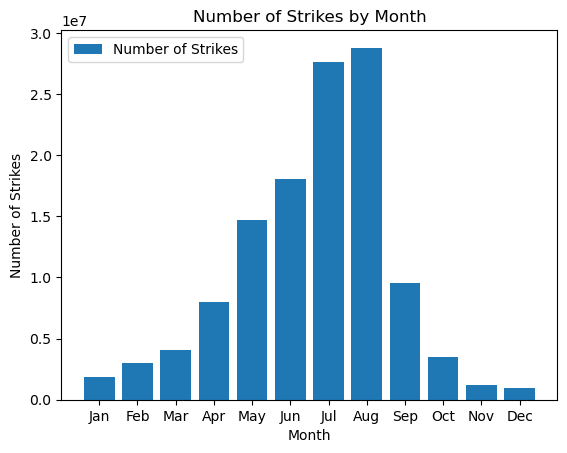

In [28]:
#Plot the number of strikes by month using a bar chart
plt.bar(x= df_by_month['Month_txt'], height= df_by_month['number_of_strikes'],label= 'Number of Strikes')
plt.plot()

plt.title('Number of Strikes by Month')
plt.xlabel('Month')
plt.ylabel('Number of Strikes')

plt.legend()
plt.show()

In [ ]:
#Date string manipulations with Python

In [ ]:
#Break date information

df['Week']= df['date'].dt.strftime('%Y-W%V')
df['Month2']= df['date'].dt.strftime('%Y-%m')
df['Querter']= df['date'].dt.to_period('Q').dt.strftime('%Y-Q%q') # '%Y-Q%q', 1st 'Q' si to let know we are talking about Querter, 2nd q is to format the date into querters
df['Year']= df['date'].dt.strftime('%Y')

df.head()

In [30]:
df.to_csv('C:/Users/MSI Modern/Downloads/EDA on NOAA, GADAPC 13- 12.csv')

#Export the file then import again try to speed up the process

In [32]:
sys.path.append("C:/Users/MSI Modern/Downloads/Python Dataset/EDA on NOAA, GADAPC 13- 12.csv")

In [34]:
df= pd.read_csv("C:/Users/MSI Modern/Downloads/Python Dataset/EDA on NOAA, GADAPC 13- 12.csv")
df.head()

,Unnamed: 0,date,number_of_strikes,center_point_geom,Month,Month_txt,Week,Month2,Querter,Year
0,0,2016-08-05,16,POINT(-101.5 24.7),8,Aug,2016-W31,2016-08,2016-Q3,2016
1,1,2016-08-05,16,POINT(-85 34.3),8,Aug,2016-W31,2016-08,2016-Q3,2016
2,2,2016-08-05,16,POINT(-89 41.4),8,Aug,2016-W31,2016-08,2016-Q3,2016
3,3,2016-08-05,16,POINT(-89.8 30.7),8,Aug,2016-W31,2016-08,2016-Q3,2016
4,4,2016-08-05,16,POINT(-86.2 37.9),8,Aug,2016-W31,2016-08,2016-Q3,2016


In [42]:
df['date']=pd.to_datetime(df['date'])

In [44]:
#Plot new dataframe view of just 2018 data, summed by week

df_by_week_2018= df[df['Year']=='2018'].sum().reset_index.groupby(['Week'])
#This code group the data by Year than orders by Week

plt.bar(x= df_by_week_2018['Week'], height= df_by_week_2018['number_of_strikes'], label= 'Number of Strikes')
                          #^Select wat to show in Xaxis    #Select wat to show in Yaxs from which which dataframe
plt.plot() #This is use to place argument in th X/Y label and title

plt.title('Number of Strikes by Week in 2018')
plt.xlabel('Week')
plt.ylabel('Number of Strikes')

plt.legend()
plt.show()

TypeError: 'DatetimeArray' with dtype datetime64[ns] does not support reduction 'sum'

In [46]:
#From ChatGPT
#The error you're encountering, TypeError: 'DatetimeArray' with dtype datetime64[ns] does not support reduction 'sum', 
#Indicates that you're trying to apply the sum() function to a datetime64 column or a group that contains date-related values (such as week numbers) rather than numerical values, which can't be summed directly.


#Let's break down your approach and correct the logic:
#Key Points:
#Filtering 2018 Data: You are correctly filtering the data for the year 2018, but you are trying to apply sum() on the entire DataFrame, including datetime64 columns. 
#Since the sum() operation should be applied only to numerical columns, like the number of strikes.

#Group Data by Week: You want to group the data by week and sum the number of strikes per week. Assuming you have a column like number_of_strikes to represent the counts, you should group by the Week column and sum the strikes.

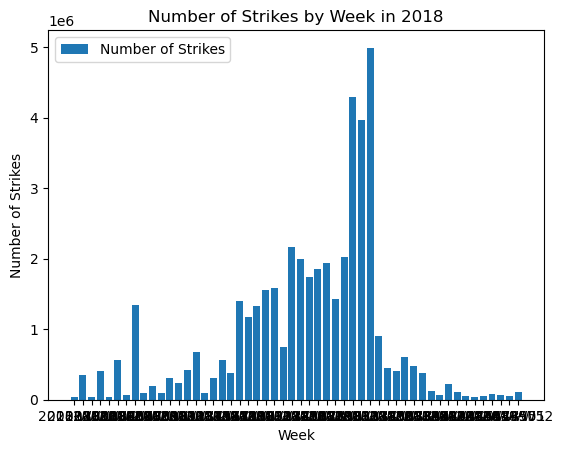

In [48]:
# First, filter the DataFrame for 2018 data
df_2018 = df[df['Year'] == 2018]

# Group by 'Week' and sum the 'number_of_strikes' for each week
df_by_week_2018 = df_2018.groupby('Week')['number_of_strikes'].sum().reset_index()

# Plot the data using a bar chart
plt.bar(x=df_by_week_2018['Week'], height=df_by_week_2018['number_of_strikes'], label='Number of Strikes')

# Add labels, title, and legend
plt.title('Number of Strikes by Week in 2018')
plt.xlabel('Week')
plt.ylabel('Number of Strikes')

plt.legend()
plt.show()

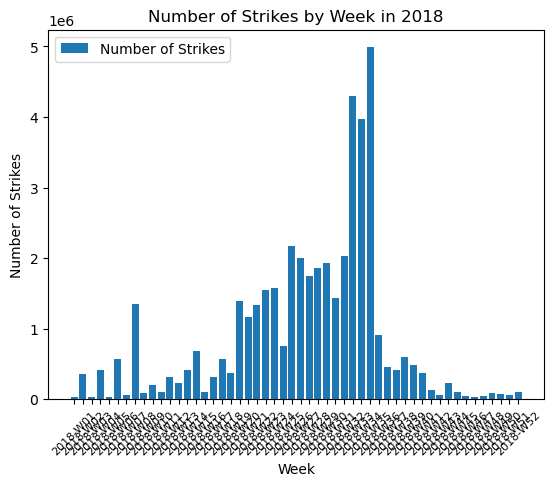

In [50]:
# First, filter the DataFrame for 2018 data
df_2018 = df[df['Year'] == 2018]

# Group by 'Week' and sum the 'number_of_strikes' for each week
df_by_week_2018 = df_2018.groupby('Week')['number_of_strikes'].sum().reset_index()

# Plot the data using a bar chart
plt.bar(x=df_by_week_2018['Week'], height=df_by_week_2018['number_of_strikes'], label='Number of Strikes')

# Add labels, title, and legend
plt.title('Number of Strikes by Week in 2018')
plt.xlabel('Week')
plt.ylabel('Number of Strikes')
plt.xticks(rotation= 45, fontsize= 8), #Rotate X-axis labels(Word) and decrease the font size
#^ To adjust the graph 

plt.legend()
plt.show()

In [52]:
#Group 2016-2018 data by quarter and sum
#df_by_quarter= df.groupby(['Querter'])sum().reset_index() 
#^Wrong example
df_by_quarter= df.groupby(['Querter'])['number_of_strikes'].sum().reset_index() 

#Column to divide the total number of Strike by one million

df_by_quarter['Number_of_Stirkes_Formatted']= df_by_quarter['number_of_strikes'].div(1000000).round(1)

df_by_quarter.head()

,Querter,number_of_strikes,Number_of_Stirkes_Formatted
0,2016-Q1,2683798,2.7
1,2016-Q2,15084857,15.1
2,2016-Q3,21843820,21.8
3,2016-Q4,1969754,2.0
4,2017-Q1,2444279,2.4


In [54]:
#From ChatGPT
#For the wrong example, AttributeError: 'SeriesGroupBy' object has no attribute 'div' will pop out
#Occurs because you're trying to use .div() on the grouped DataFrame object without first aggregating the grouped data
#When you use groupby(), it creates a grouped object, but you need to perform an aggregation 
#E.g., sum(), mean(), etc.) before performing operations on the grouped data.

#Correct Approach
#Group by Quarter and Sum: You need to first group by the 'Quarter' and then sum the number_of_strikes for each quarter.
#Divide by One Million: After summing the strikes, you can perform the division and formatting

#Why the Error Occurred:
#The .div() function is meant to be used on a pandas Series or DataFrame
#But when you group your data using groupby(), you need to aggregate the grouped object(e.g., by summing) before applying functions like .div().

#Important Notes:
#Ensure that your 'Quarter' column is properly defined
#If your original data contains a datetime column, you may need to extract the quarter from it 
#Using pd.to_datetime() and .dt.quarter like this:
#df['Quarter'] = pd.to_datetime(df['Date']).dt.quarter
#The astype function should have parentheses to convert data types. If needed, you can add it like this: .astype(float) or .astype(str).

In [56]:
def addlabels(x, y, labels):
    '''
    Iterates over data and plots text labels above each bar of bar graph
    '''
    for i in range(len(x)):
        plt.text(i, y[i], labels[i], ha='center', va='bottom')

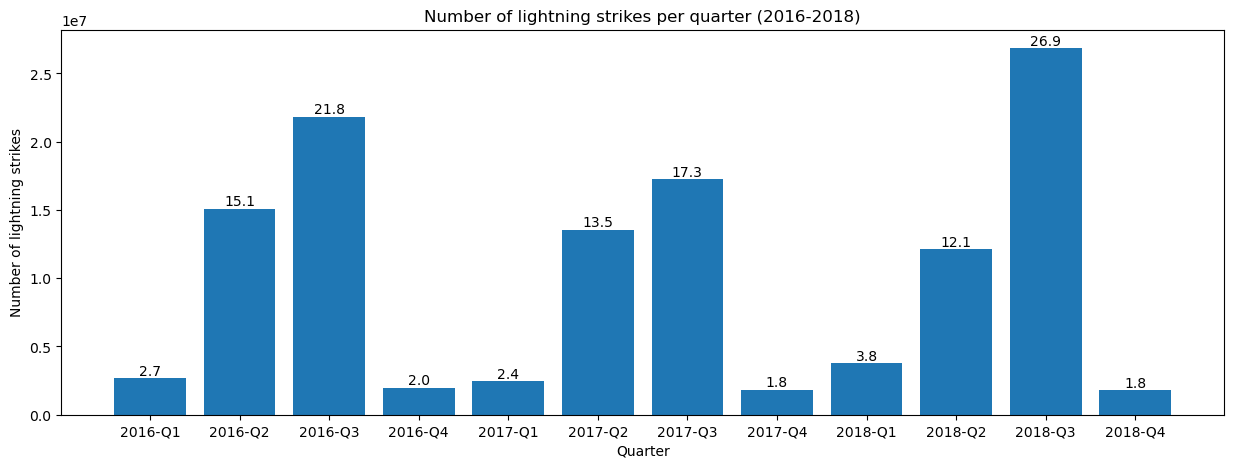

In [58]:
plt.figure(figsize=(15,5)) #Setting the lenght and Height of the graph
plt.bar(x= df_by_quarter['Querter'], height= df_by_quarter['number_of_strikes']) 
addlabels(df_by_quarter['Querter'], df_by_quarter['number_of_strikes'], df_by_quarter['Number_of_Stirkes_Formatted'])
plt.plot()
plt.xlabel('Quarter')
plt.ylabel('Number of lightning strikes')
plt.title('Number of lightning strikes per quarter (2016-2018)')
plt.show()

In [60]:
#Create 2 new column 
df_by_quarter['Quarter_Number']= df_by_quarter['Querter'].str[-2:]
df_by_quarter['Year']= df_by_quarter['Querter'].str[:4]
df_by_quarter.head()

,Querter,number_of_strikes,Number_of_Stirkes_Formatted,Quarter_Number,Year
0,2016-Q1,2683798,2.7,Q1,2016
1,2016-Q2,15084857,15.1,Q2,2016
2,2016-Q3,21843820,21.8,Q3,2016
3,2016-Q4,1969754,2.0,Q4,2016
4,2017-Q1,2444279,2.4,Q1,2017


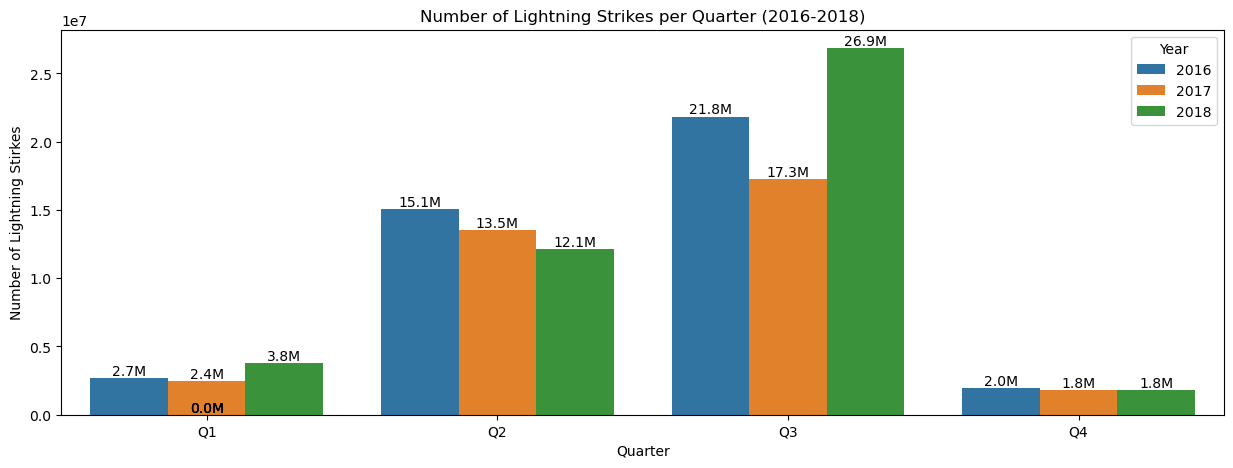

In [62]:
plt.figure(figsize= (15,5))
p= sns.barplot(
    data= df_by_quarter,
    x= 'Quarter_Number',
    y= 'number_of_strikes',
    hue= 'Year')

for b in p.patches:
    p.annotate(str(round(b.get_height()/1000000, 1))+ 'M',
               (b.get_x()+ b.get_width()/ 2., b.get_height()+ 1.2e6),
                ha= 'center', va= 'bottom',
                xytext= (0, -12),
                textcoords= 'offset points')

plt.xlabel('Quarter')
plt.ylabel('Number of Lightning Stirkes')
plt.title('Number of Lightning Strikes per Quarter (2016-2018)')
plt.show()